<a href="https://colab.research.google.com/github/greeshmakrishnan00/EDA-ML-DL-Projects/blob/main/AL_BASED_TRAFFIC_CONGESTION_PREDICTION_PROJECT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement

Traffic congestion has become a major challenge in modern urban transportation systems due to increasing vehicle numbers, population growth, road infrastructure limitations, accidents, adverse weather conditions, and special events. Congestion results in longer travel times, higher fuel consumption, increased air pollution, and reduced transportation efficiency. This project aims to develop an AI-Based Traffic Congestion Prediction System that utilizes machine learning and deep learning techniques to predict traffic congestion levels based on factors such as vehicle count, average speed, road capacity, weather conditions, accident frequency, rainfall, signal delays, public transport usage, road type, and event-related traffic. By accurately forecasting the Traffic Congestion Index, the system can support traffic authorities, urban planners, and commuters in making proactive decisions to optimize traffic flow, reduce delays, and improve overall urban mobility.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression

In [ ]:
df=pd.read_csv("/content/AI_Traffic_Congestion.csv")
df

,Weather_Condition,Road_Type,Day_Type,Event_Type,Time_Slot,Vehicle_Count,Average_Speed,Road_Capacity,Accident_Count,Rainfall_mm,Signal_Delay_sec,Public_Transport_Usage,Traffic_Congestion_Index
0,Rainy,Highway,Weekday,NaN,Morning,2838,64.92,5394,4,3.36,78.90,0,64.34
1,Cloudy,Rural,Weekday,NaN,Evening,4726,30.32,4231,4,35.54,136.61,30,100.00
2,Foggy,Highway,Weekday,NaN,Night,3591,51.06,2595,1,3.57,100.21,56,69.46
3,Rainy,Highway,Weekend,NaN,Afternoon,868,97.76,3776,2,11.50,33.73,38,0.00
4,Clear,Rural,Weekend,NaN,Night,2969,59.69,3328,0,0.81,81.21,60,34.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Foggy,Rural,Weekend,NaN,Evening,3840,46.61,4164,2,18.40,111.30,93,78.34
49996,Foggy,Highway,Weekday,NaN,Morning,4102,42.84,5763,4,0.94,120.31,31,95.59
49997,Rainy,Rural,Weekday,NaN,Morning,2626,67.19,5241,1,13.72,72.40,42,31.31
49998,Clear,Urban,Weekday,NaN,Evening,4200,39.14,1644,0,12.20,127.18,0,97.13


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Weather_Condition         50000 non-null  object 
 1   Road_Type                 50000 non-null  object 
 2   Day_Type                  50000 non-null  object 
 3   Event_Type                7692 non-null   object 
 4   Time_Slot                 50000 non-null  object 
 5   Vehicle_Count             50000 non-null  int64  
 6   Average_Speed             50000 non-null  float64
 7   Road_Capacity             50000 non-null  int64  
 8   Accident_Count            50000 non-null  int64  
 9   Rainfall_mm               50000 non-null  float64
 10  Signal_Delay_sec          50000 non-null  float64
 11  Public_Transport_Usage    50000 non-null  int64  
 12  Traffic_Congestion_Index  50000 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 5.0+ MB


In [ ]:
df.isnull().sum()

,0
Weather_Condition,0
Road_Type,0
Day_Type,0
Event_Type,42308
Time_Slot,0
Vehicle_Count,0
Average_Speed,0
Road_Capacity,0
Accident_Count,0
Rainfall_mm,0


In [ ]:
df.dropna(subset=['Event_Type'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Weather_Condition,0
Road_Type,0
Day_Type,0
Event_Type,0
Time_Slot,0
Vehicle_Count,0
Average_Speed,0
Road_Capacity,0
Accident_Count,0
Rainfall_mm,0


In [ ]:
target='Traffic_Congestion_Index'

In [ ]:
df[target].value_counts()

,count
Traffic_Congestion_Index,
0.00,1458
100.00,1290
44.18,6
49.84,5
20.43,5
...,...
50.64,1
19.67,1
98.55,1


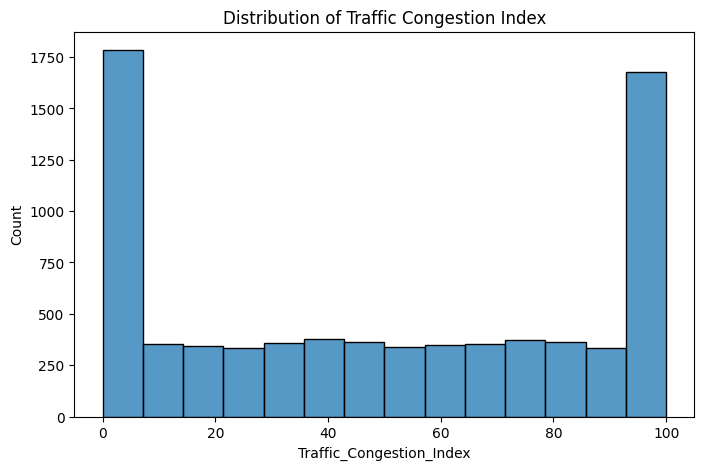

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Traffic_Congestion_Index'])
plt.title('Distribution of Traffic Congestion Index')
plt.show()

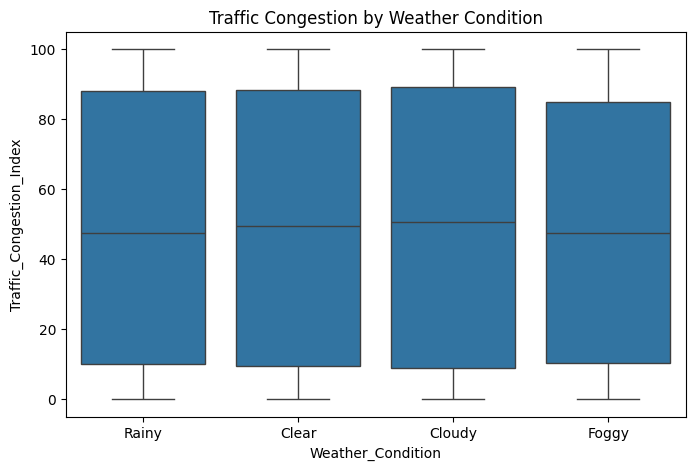

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Weather_Condition',
            y='Traffic_Congestion_Index',
            data=df)
plt.title('Traffic Congestion by Weather Condition')
plt.show()

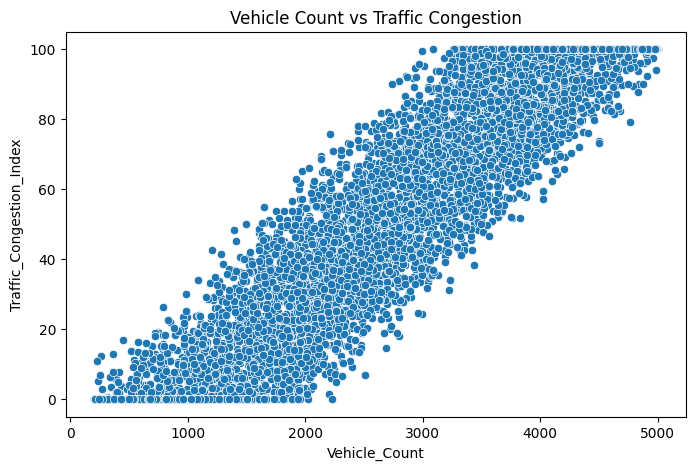

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Vehicle_Count',
                y='Traffic_Congestion_Index',
                data=df)
plt.title('Vehicle Count vs Traffic Congestion')
plt.show()

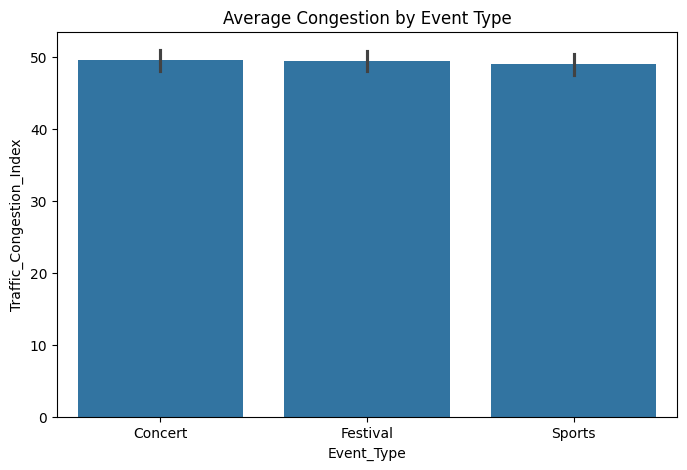

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Event_Type',
            y='Traffic_Congestion_Index',
            data=df)
plt.title('Average Congestion by Event Type')
plt.show()

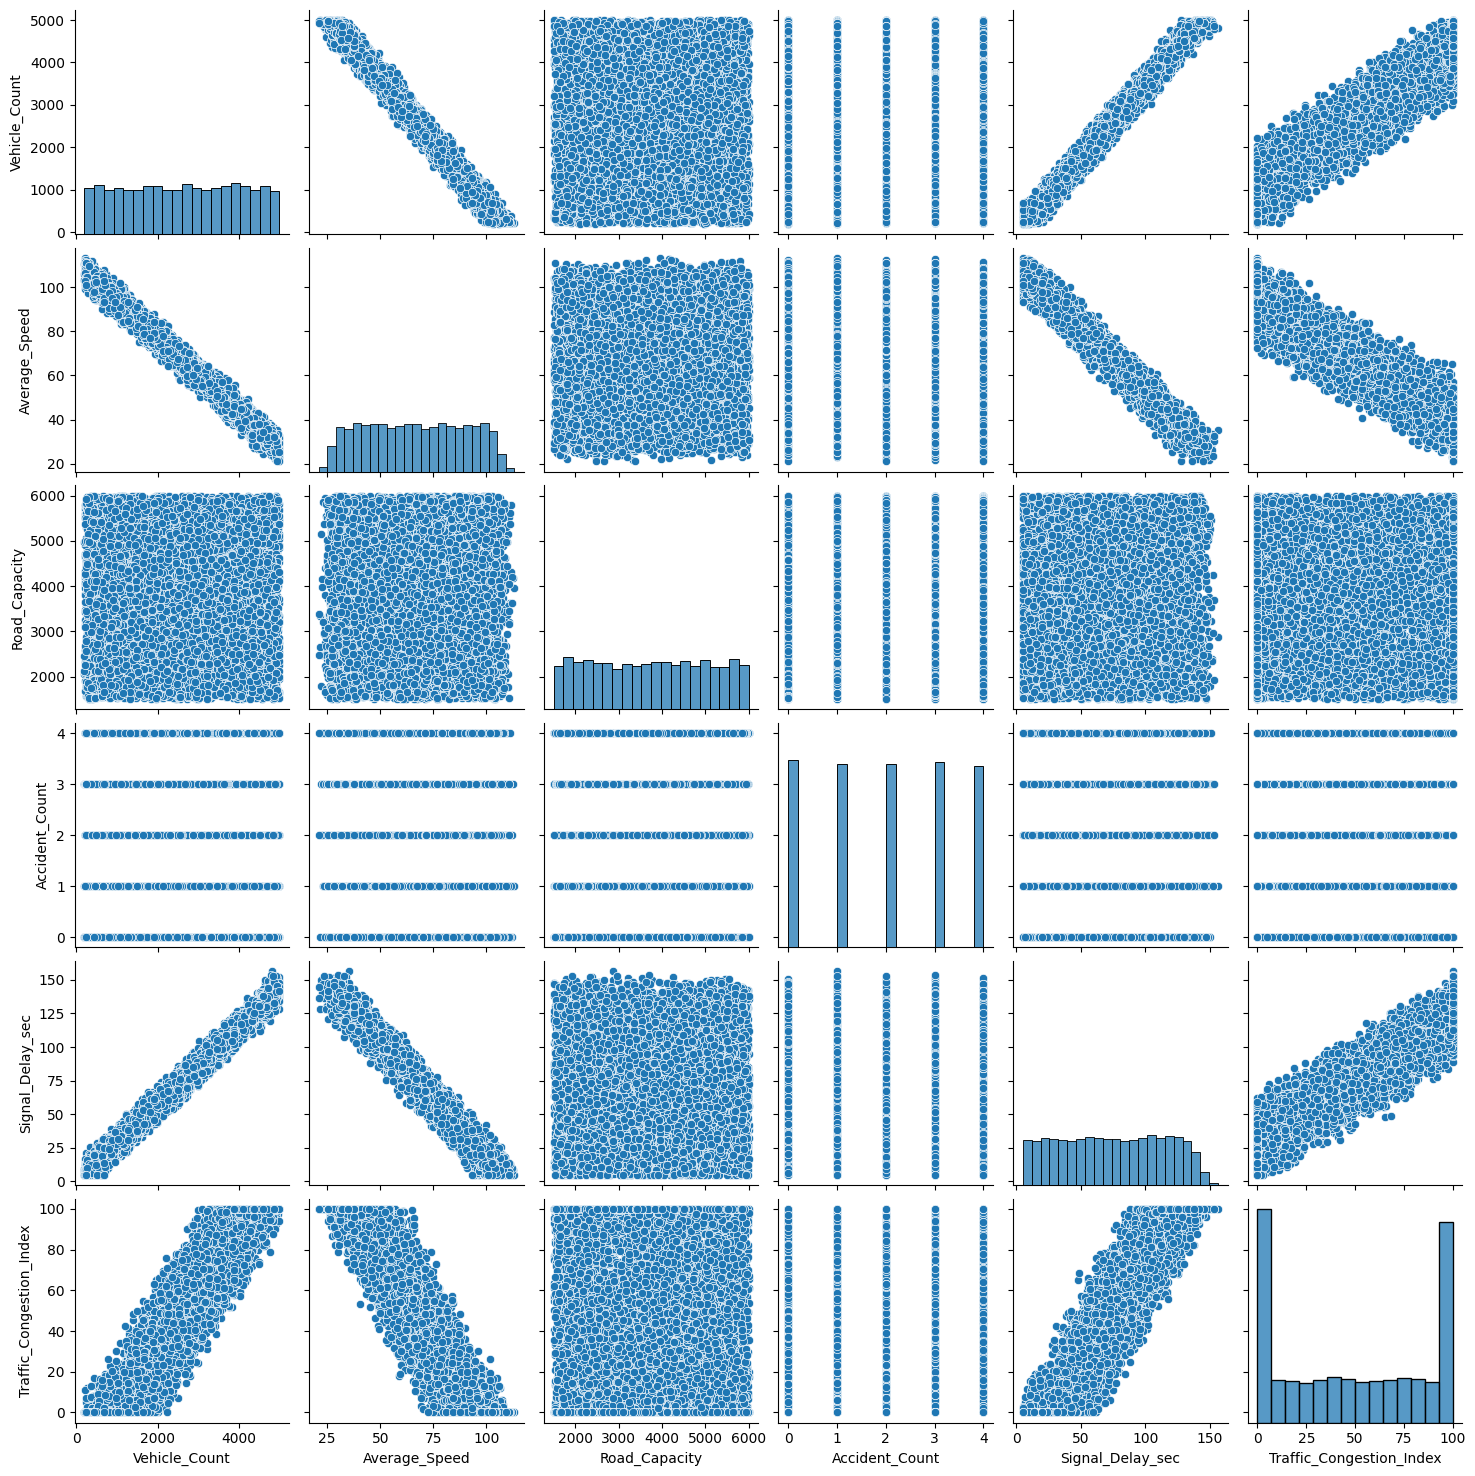

In [ ]:
cols = ['Vehicle_Count',
        'Average_Speed',
        'Road_Capacity',
        'Accident_Count',
        'Signal_Delay_sec',
        'Traffic_Congestion_Index']

sns.pairplot(df[cols])
plt.show()

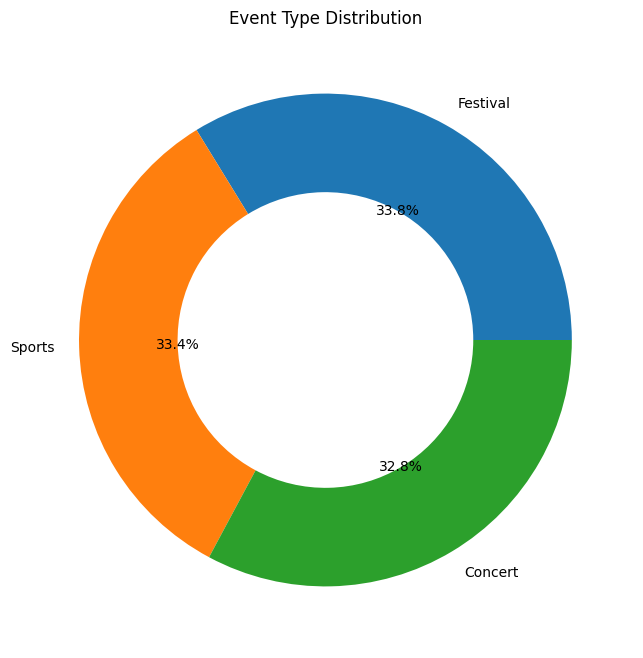

In [ ]:
event_counts = df['Event_Type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(event_counts,
        labels=event_counts.index,
        autopct='%1.1f%%',
        wedgeprops=dict(width=0.4))

plt.title('Event Type Distribution')
plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Vehicle_Count', 'Average_Speed', 'Road_Capacity', 'Accident_Count',
       'Rainfall_mm', 'Signal_Delay_sec', 'Public_Transport_Usage',
       'Traffic_Congestion_Index'],
      dtype='object')

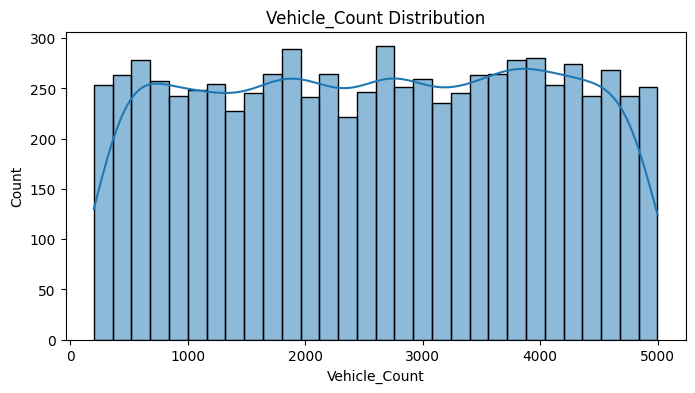

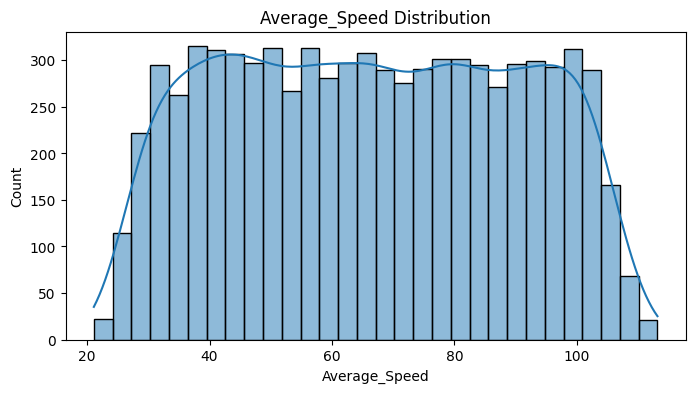

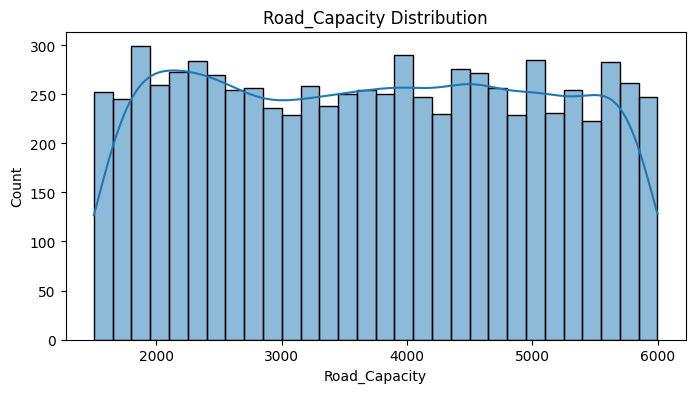

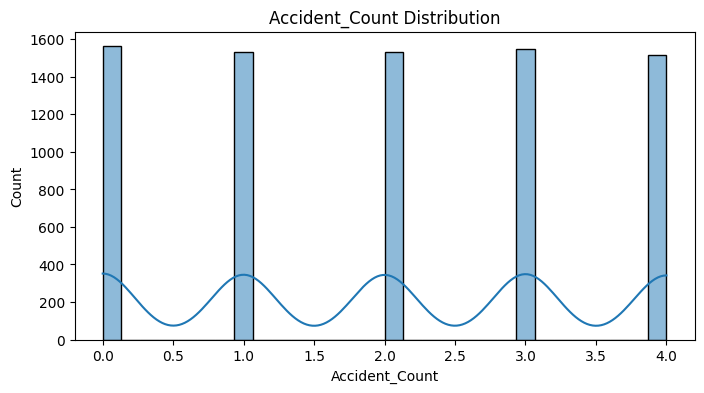

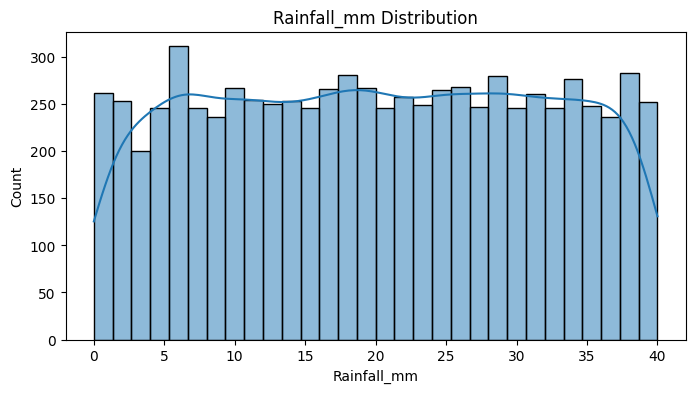

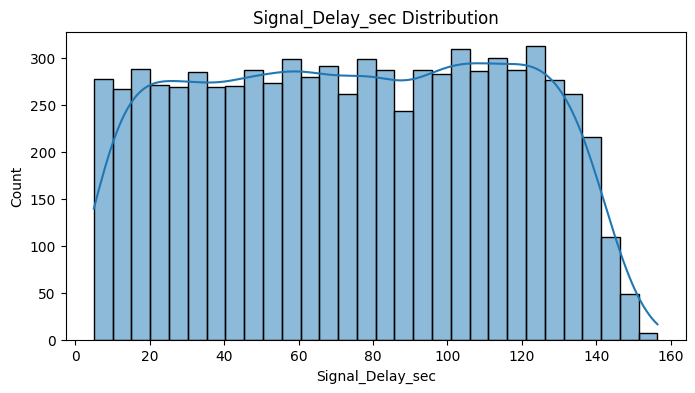

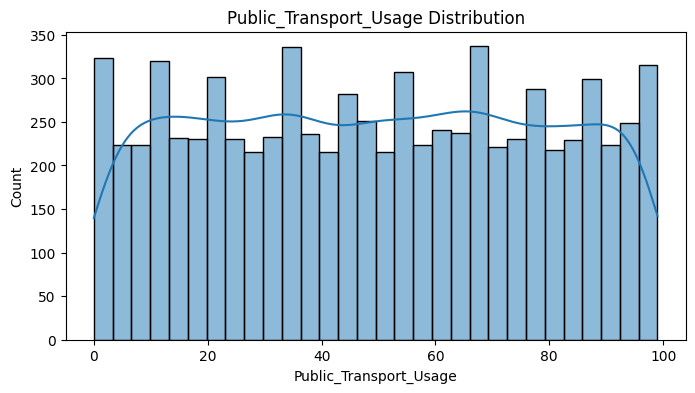

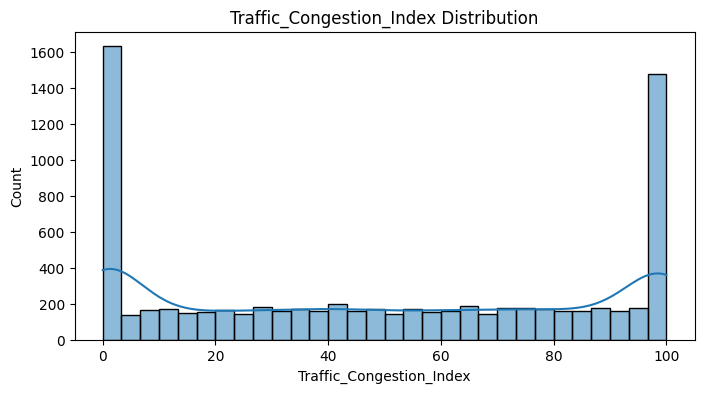

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['Weather_Condition', 'Road_Type', 'Day_Type', 'Event_Type',
       'Time_Slot'],
      dtype='object')

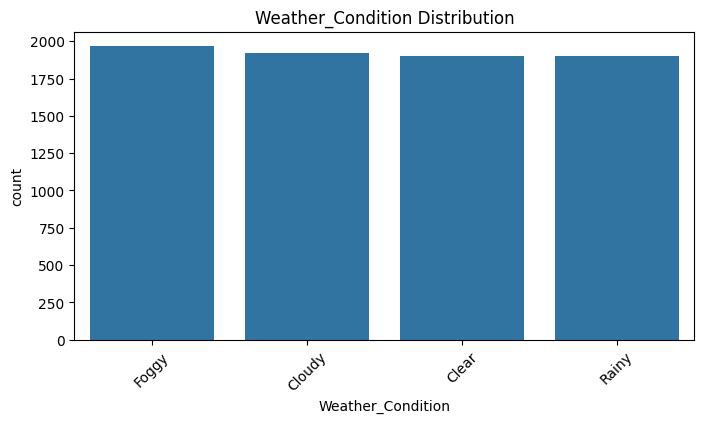

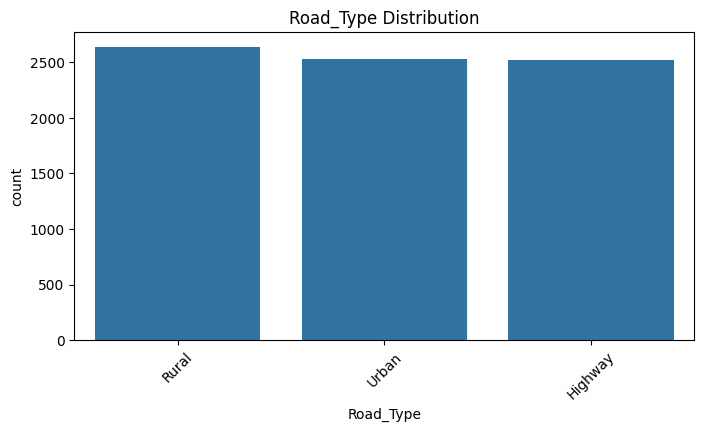

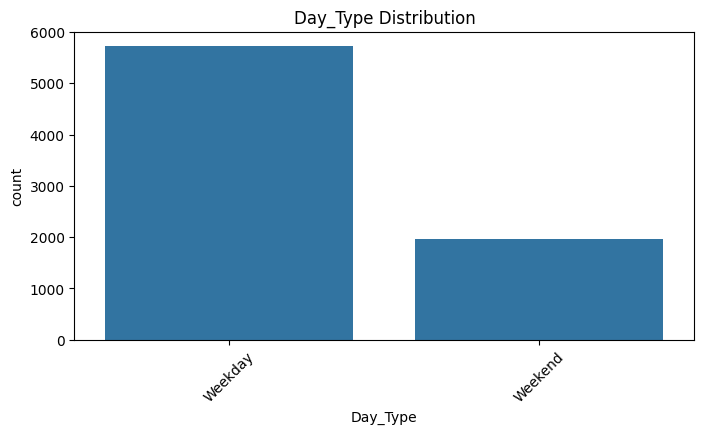

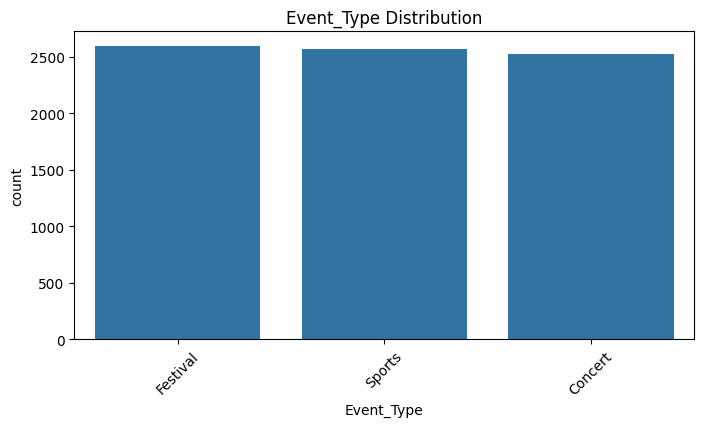

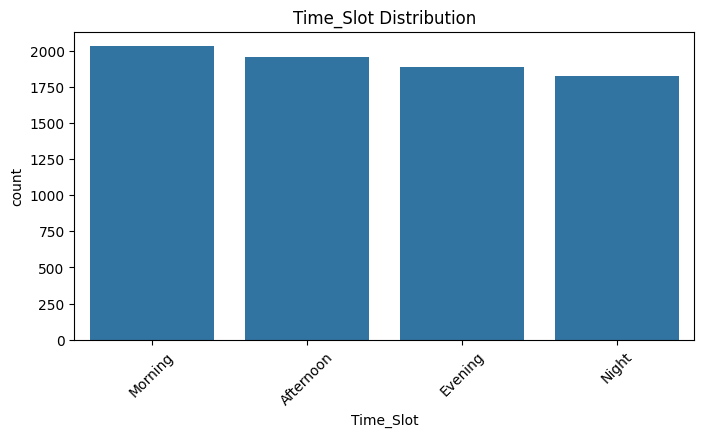

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7692 entries, 22 to 49999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Weather_Condition         7692 non-null   object 
 1   Road_Type                 7692 non-null   object 
 2   Day_Type                  7692 non-null   object 
 3   Event_Type                7692 non-null   object 
 4   Time_Slot                 7692 non-null   object 
 5   Vehicle_Count             7692 non-null   int64  
 6   Average_Speed             7692 non-null   float64
 7   Road_Capacity             7692 non-null   int64  
 8   Accident_Count            7692 non-null   int64  
 9   Rainfall_mm               7692 non-null   float64
 10  Signal_Delay_sec          7692 non-null   float64
 11  Public_Transport_Usage    7692 non-null   int64  
 12  Traffic_Congestion_Index  7692 non-null   float64
dtypes: float64(4), int64(4), object(5)
memory usage: 841.3+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Weather_Condition"]=le.fit_transform(df["Weather_Condition"])
df["Road_Type"]=le.fit_transform(df["Road_Type"])
df["Day_Type"]=le.fit_transform(df["Day_Type"])
df["Event_Type"]=le.fit_transform(df["Event_Type"])

In [ ]:
time_mapping = {
    'Morning': 1,
    'Afternoon': 2,
    'Evening': 3,
    'Night': 4
}

df['Time_Slot'] = df['Time_Slot'].map(time_mapping)

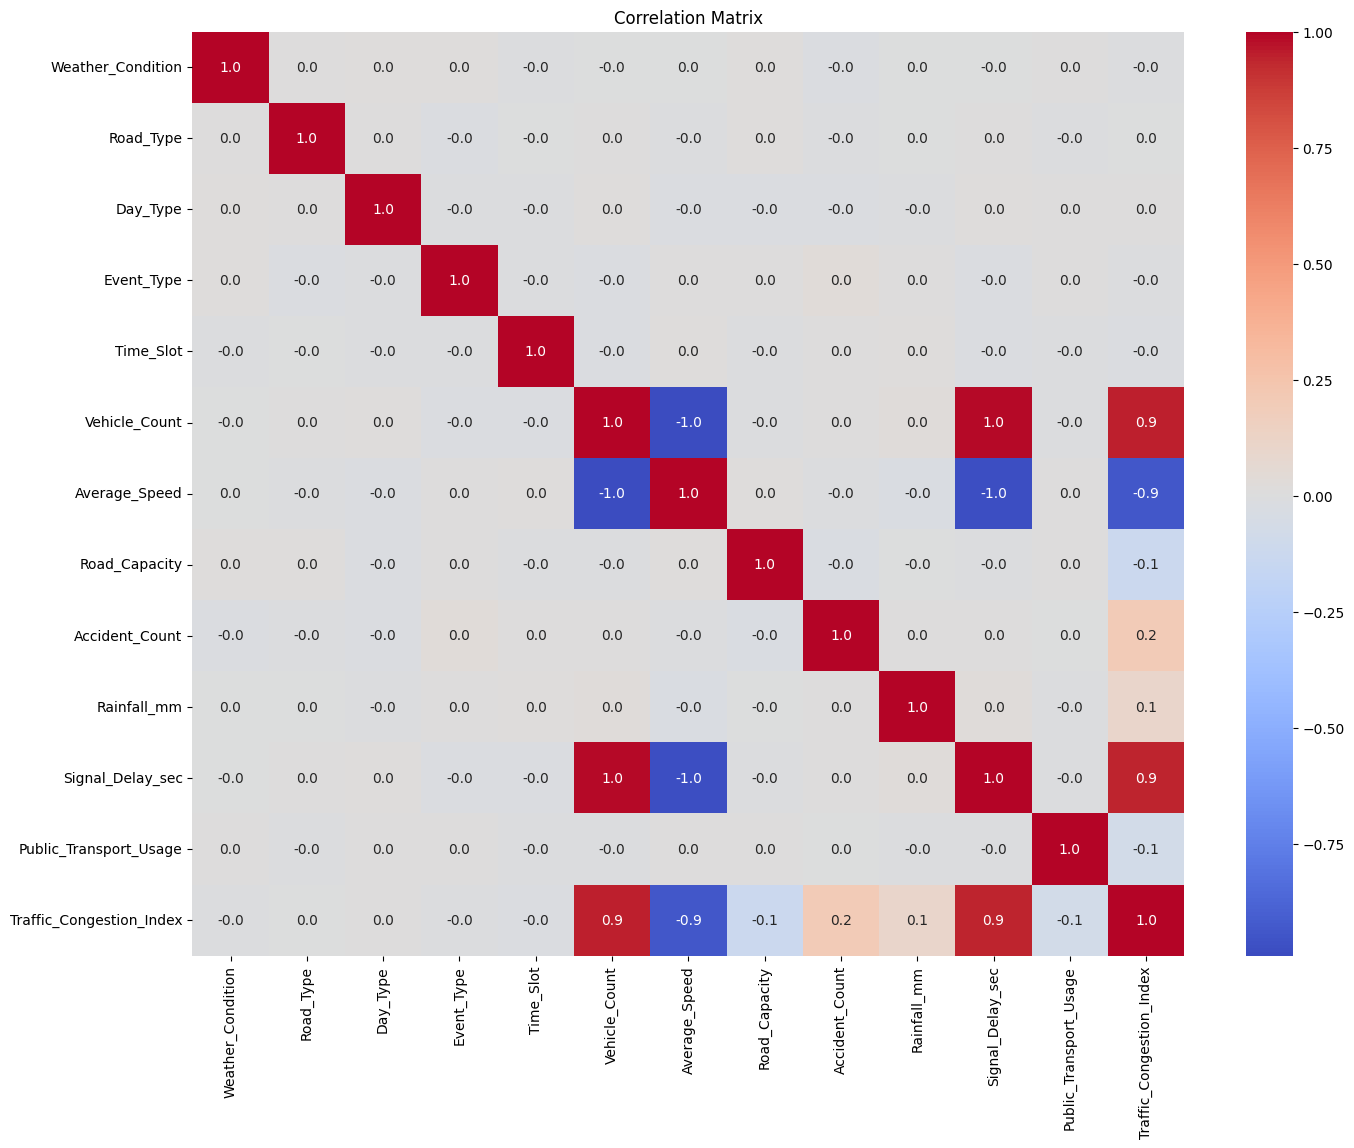

In [ ]:
core_matrix=df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(core_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

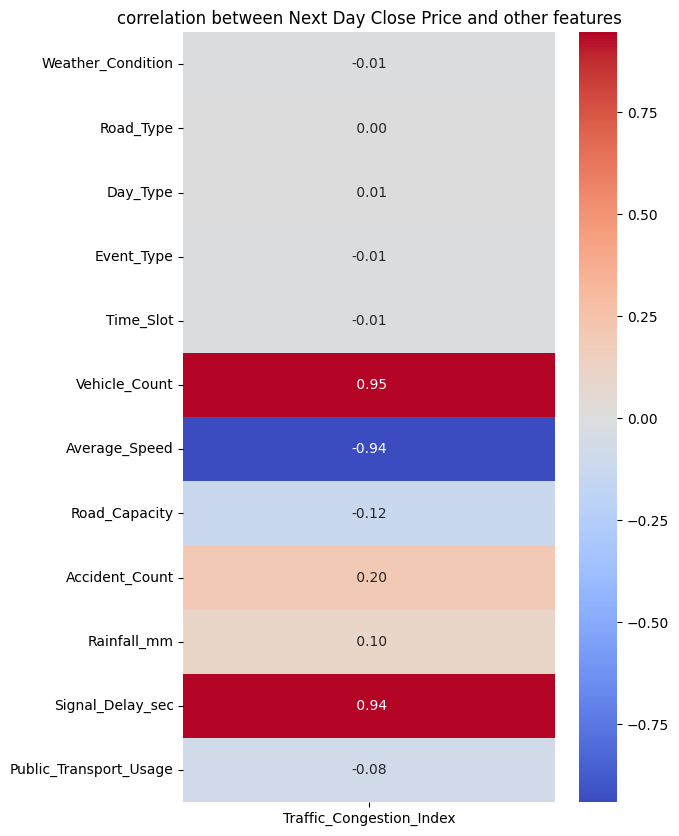

In [ ]:
plt.figure(figsize=(6,10))

status_corr=df.corr()["Traffic_Congestion_Index"]
status_corr=status_corr.drop("Traffic_Congestion_Index")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between Next Day Close Price and other features')
plt.show()

In [ ]:
df.columns

Index(['Weather_Condition', 'Road_Type', 'Day_Type', 'Event_Type', 'Time_Slot',
       'Vehicle_Count', 'Average_Speed', 'Road_Capacity', 'Accident_Count',
       'Rainfall_mm', 'Signal_Delay_sec', 'Public_Transport_Usage',
       'Traffic_Congestion_Index'],
      dtype='object')

In [ ]:
df.drop(['Average_Speed','Road_Capacity', 'Day_Type','Signal_Delay_sec'],axis=1,inplace=True)

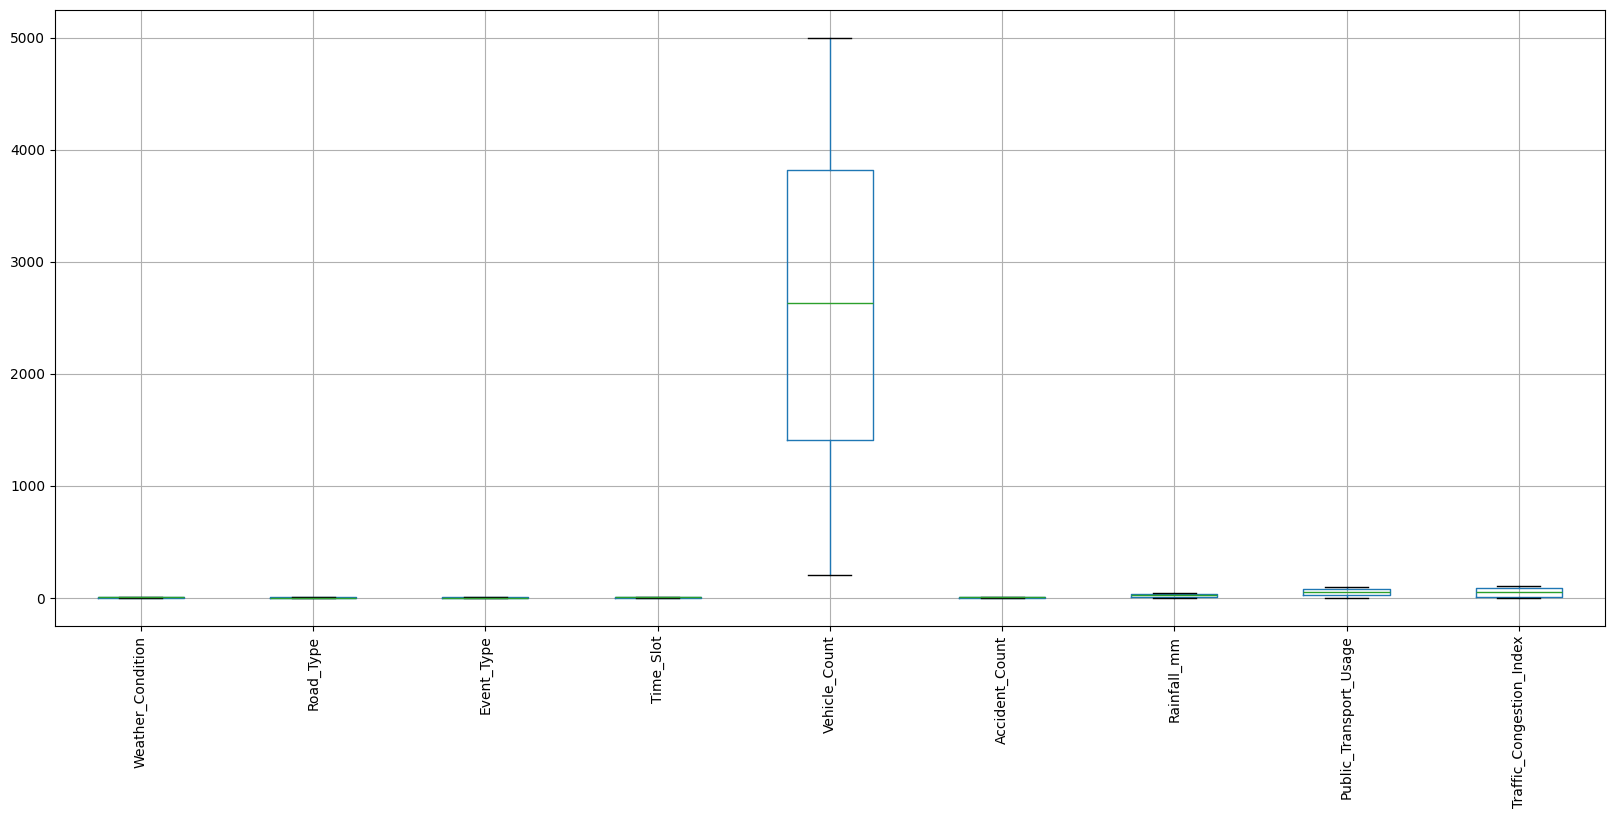

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(7692, 9)

In [ ]:
df.columns

Index(['Weather_Condition', 'Road_Type', 'Event_Type', 'Time_Slot',
       'Vehicle_Count', 'Accident_Count', 'Rainfall_mm',
       'Public_Transport_Usage', 'Traffic_Congestion_Index'],
      dtype='object')

In [ ]:
features=['Weather_Condition', 'Road_Type', 'Event_Type', 'Time_Slot',
       'Vehicle_Count', 'Accident_Count', 'Rainfall_mm',
       'Public_Transport_Usage']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
x=df[['Weather_Condition', 'Road_Type', 'Event_Type', 'Time_Slot',
       'Vehicle_Count', 'Accident_Count', 'Rainfall_mm',
       'Public_Transport_Usage']]
y=df['Traffic_Congestion_Index']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.94


# Machine Learning

In [ ]:
#DecisionTree

from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.95


In [ ]:
# SVR

from sklearn.svm import SVR
model=SVR(kernel="poly",degree=8)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.43


In [ ]:
#Random forest

from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.98


In [ ]:
#GradientBooster
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create model
gb_model = GradientBoostingRegressor(random_state=42)

# Train model
gb_model.fit(x_train, y_train)

# Predict
y_pred_gb = gb_model.predict(x_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R² Score: 0.9772908417076341
MAE: 4.342618157809717
RMSE: 5.684174125966321


In [ ]:
# ADABOOST

from sklearn.ensemble import AdaBoostRegressor

model=AdaBoostRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.95


In [ ]:
#xgboost

from  xgboost import XGBRegressor
model=XGBRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.97


# KFold

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df.drop('Traffic_Congestion_Index', axis=1)
y = df['Traffic_Congestion_Index']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

best_r2 = -np.inf
best_fold = -1

best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):

    print(f"\nFold {fold}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R² Score:", r2)
    print("RMSE:", rmse)

    if r2 > best_r2:

        best_r2 = r2
        best_fold = fold

        best_X_train = X_train
        best_y_train = y_train

        best_X_test = X_test
        best_y_test = y_test

        best_y_pred = y_pred

print(f"\nBest Fold: {best_fold} with R² Score: {best_r2}")


Fold 1
R² Score: 0.9436454551693821
RMSE: 8.934810054090297

Fold 2
R² Score: 0.9422310094820927
RMSE: 9.127955521756503

Fold 3
R² Score: 0.9459789285088278
RMSE: 8.87157174414055

Fold 4
R² Score: 0.9475079789344258
RMSE: 8.626182577613498

Fold 5
R² Score: 0.9459189655387206
RMSE: 8.718809121790226

Best Fold: 4 with R² Score: 0.9475079789344258


In [ ]:
model=LinearRegression()
model.fit(best_X_train,best_y_train)
print("Linear Regression:",model.score(best_X_test,best_y_test))

Linear Regression: 0.9475079789344258


In [ ]:
model=RandomForestRegressor()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.9747799742968506


In [ ]:
model=DecisionTreeRegressor()
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.9497119969347803


In [ ]:
model=SVR()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.9144068704568441


In [ ]:
model=GradientBoostingRegressor(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.9765909137606477


In [ ]:
model=AdaBoostRegressor()
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.9481331570942222


In [ ]:
model=XGBRegressor()
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.972763271161263


In [ ]:
df.shape

(7692, 9)

#Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Scale the data for deep learning
scaler_dl = MinMaxScaler()
x_train_scaled_dl = scaler_dl.fit_transform(best_X_train)
x_test_scaled_dl = scaler_dl.transform(best_X_test)

# Model
model = Sequential()
model.add(Dense(110, input_shape=(x_train_scaled_dl.shape[1],), activation='relu'))  # Hidden Layer 1
model.add(Dense(44, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1))

# Compile with regression metrics
model.compile(optimizer=Adam(learning_rate=0.001), # Adjusted learning rate for better convergence
              loss='mean_squared_error')

# Train
model.fit(x_train_scaled_dl, best_y_train, epochs=50, batch_size=32, verbose=0) # Increased epochs and added batch_size

# Predict
y_pred = model.predict(x_test_scaled_dl)

# Calculate MSE and MAE
mse = mean_squared_error(best_y_test, y_pred)
mae = mean_absolute_error(best_y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean Squared Error: 34.279185513571576
Mean Absolute Error: 4.393849047192207


# Conclusion

### Conclusion

This project successfully developed an AI-Based Traffic Congestion Prediction system to forecast traffic congestion levels using transportation, environmental, and road-related factors. Multiple machine learning and deep learning models were trained and evaluated on the dataset. Among all the models, Gradient Boosting achieved the highest predictive performance with an R² score of 97.66%, followed closely by Random Forest (97.48%), XGBoost (97.28%), Decision Tree (94.97%), AdaBoost (94.81%), Linear Regression (94.75%), and SVM (91.44%). The Deep Learning model also demonstrated strong predictive capability, achieving a Mean Squared Error (MSE) of 34.28 and a Mean Absolute Error (MAE) of 4.39. The results indicate that ensemble-based machine learning algorithms are highly effective in capturing the relationships between traffic-related variables and congestion levels. Overall, the developed system provides accurate traffic congestion predictions and can support intelligent transportation systems, traffic management authorities, and urban planners in improving traffic flow, reducing delays, and enabling data-driven decision-making.


# Future scope


The AI-Based Traffic Congestion Prediction system can be further enhanced by integrating real-time traffic data from GPS devices, IoT sensors, traffic cameras, and navigation applications to provide live congestion forecasting. Advanced deep learning techniques such as LSTM, GRU, and Transformer models can be implemented to improve the prediction of time-dependent traffic patterns. The system can also incorporate additional factors such as road construction activities, public holidays, weather forecasts, and special events to increase prediction accuracy. Integration with intelligent transportation systems and smart city infrastructures can enable automated traffic signal control and dynamic route optimization. Furthermore, deploying the model as a web or mobile application can provide real-time traffic insights to commuters, helping reduce travel time, fuel consumption, and environmental impact while supporting efficient urban transportation management.
